PyTorch Version: 2.9.0+cu126
TorchAudio Version: 2.9.0+cu126

Testing extraction on: /kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00391/00052.mp4
✅ Success! Spectrogram Tensor Shape: torch.Size([1, 64, 94])


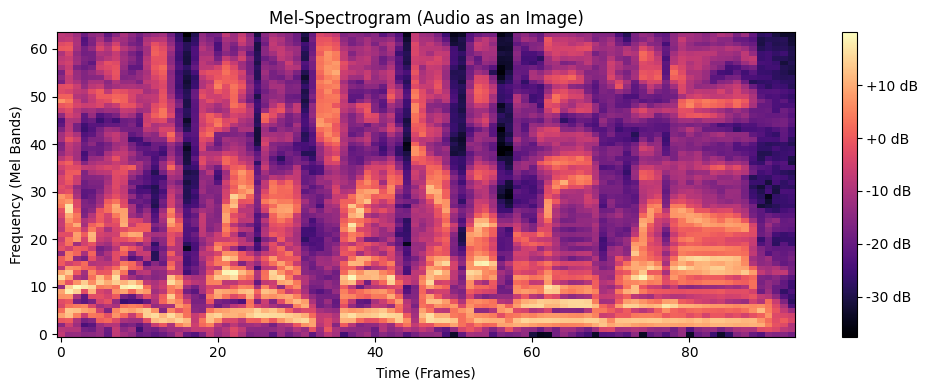

In [1]:
import os
import torch
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
import IPython.display as ipd

print(f"PyTorch Version: {torch.__version__}")
print(f"TorchAudio Version: {torchaudio.__version__}")

def extract_mel_spectrogram(video_path, target_sample_rate=16000, duration=3.0):
    """
    Extracts audio from an mp4, resamples it, trims/pads it to a fixed duration,
    and converts it into a Mel-Spectrogram tensor.
    """
    try:
        # Load audio directly from the video file
        waveform, sample_rate = torchaudio.load(video_path)
        
        # Convert stereo to mono by averaging channels if necessary
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)
            
        # Resample to standardize all audio to 16kHz
        if sample_rate != target_sample_rate:
            resampler = T.Resample(orig_freq=sample_rate, new_freq=target_sample_rate)
            waveform = resampler(waveform)
            
        # Fix the length of the audio (e.g., exactly 3 seconds)
        num_samples = int(target_sample_rate * duration)
        if waveform.shape[1] > num_samples:
            waveform = waveform[:, :num_samples] # Trim
        elif waveform.shape[1] < num_samples:
            pad_amount = num_samples - waveform.shape[1]
            waveform = torch.nn.functional.pad(waveform, (0, pad_amount)) # Pad with silence
            
        # Convert to Mel-Spectrogram
        mel_transform = T.MelSpectrogram(
            sample_rate=target_sample_rate,
            n_fft=1024,
            hop_length=512,
            n_mels=64
        )
        mel_spec = mel_transform(waveform)
        
        # Convert to decibels (log scale) for better visual/neural network contrast
        amplitude_to_db = T.AmplitudeToDB()
        mel_spec_db = amplitude_to_db(mel_spec)
        
        return waveform, mel_spec_db, target_sample_rate
        
    except Exception as e:
        print(f"Error processing {video_path}: {e}")
        return None, None, None

# --- TEST IT ON A SINGLE VIDEO ---
# We will auto-search for any real video in the dataset to test
test_video = None
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if file.endswith('.mp4') and 'RealVideo' in root:
            test_video = os.path.join(root, file)
            break
    if test_video:
        break

if test_video:
    print(f"\nTesting extraction on: {test_video}")
    waveform, mel_spec_db, sr = extract_mel_spectrogram(test_video)
    
    if mel_spec_db is not None:
        print(f"✅ Success! Spectrogram Tensor Shape: {mel_spec_db.shape}")
        
        # Plot the Spectrogram
        plt.figure(figsize=(10, 4))
        plt.imshow(mel_spec_db[0].numpy(), cmap='magma', origin='lower', aspect='auto')
        plt.title('Mel-Spectrogram (Audio as an Image)')
        plt.ylabel('Frequency (Mel Bands)')
        plt.xlabel('Time (Frames)')
        plt.colorbar(format='%+2.0f dB')
        plt.tight_layout()
        plt.show()
        
        # Provide an audio player in Kaggle to hear it
        display(ipd.Audio(waveform.numpy(), rate=sr))
else:
    print("Could not find a test video. Check dataset path.")

In [2]:
import os
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader, Subset

class AudioSpectrogramDataset(Dataset):
    def __init__(self, root_dir):
        self.file_paths = []
        self.labels = []

        print(f"Searching for audio in: {root_dir}")
        
        # We walk through everything and look for the specific folder names
        # specified in the FakeAVCeleb baseline paper.
        for root_path, dirs, files in os.walk(root_dir):
            # Only look in folders that actually contain videos
            video_files = [f for f in files if f.endswith('.mp4')]
            if not video_files:
                continue
                
            # Ground Truth Logic based on Directory Names
            # 1. Fake Video + Fake Audio
            if 'FakeVideo-FakeAudio' in root_path:
                current_label = 1.0
            # 2. Real Video + Fake Audio (Cloned voice)
            elif 'RealVideo-FakeAudio' in root_path:
                current_label = 1.0
            # 3. Fake Video + Real Audio (Original voice)
            elif 'FakeVideo-RealAudio' in root_path:
                current_label = 0.0
            # 4. Real Video + Real Audio
            elif 'RealVideo-RealAudio' in root_path:
                current_label = 0.0
            else:
                continue # Skip folders that don't match the 4 categories

            for file in video_files:
                self.file_paths.append(os.path.join(root_path, file))
                self.labels.append(current_label)

        if len(self.file_paths) == 0:
            print("❌ ERROR: No videos found. Check if the dataset is attached correctly.")
        else:
            print(f"✅ Found {len(self.file_paths)} total audio tracks.")
            print(f"   - Fake Audio (Cloned): {self.labels.count(1.0)}")
            print(f"   - Real Audio (Authentic): {self.labels.count(0.0)}")

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        video_path = self.file_paths[idx]
        label = self.labels[idx]
        # extract_mel_spectrogram must be defined in Cell 1
        _, mel_spec_db, _ = extract_mel_spectrogram(video_path)
        if mel_spec_db is None:
            mel_spec_db = torch.zeros((1, 64, 94))
        return mel_spec_db, torch.tensor([label], dtype=torch.float32)

# --- AUTO-DETECT DATA PATH ---
base_input_path = '/kaggle/input'
data_path = None

# Find the deepest folder that contains 'FakeVideo-FakeAudio'
for root, dirs, files in os.walk(base_input_path):
    if 'FakeVideo-FakeAudio' in dirs:
        data_path = root
        break

if data_path:
    full_audio_dataset = AudioSpectrogramDataset(root_dir=data_path)
    
    # Only split if we actually found data
    if len(full_audio_dataset) > 0:
        dataset_size = len(full_audio_dataset)
        indices = list(range(dataset_size))
        np.random.seed(42)
        np.random.shuffle(indices)

        split = int(np.floor(0.2 * dataset_size))
        train_idx, val_idx = indices[split:], indices[:split]

        train_audio_loader = DataLoader(Subset(full_audio_dataset, train_idx), batch_size=32, shuffle=True)
        val_audio_loader = DataLoader(Subset(full_audio_dataset, val_idx), batch_size=32, shuffle=False)
        print(f"✅ Dataloaders locked and loaded.")
else:
    print("❌ CRITICAL: Could not locate FakeAVCeleb folders. Please check your 'Input' sidebar.")

Searching for audio in: /kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2
✅ Found 21560 total audio tracks.
   - Fake Audio (Cloned): 11351
   - Real Audio (Authentic): 10209
✅ Dataloaders locked and loaded.


In [3]:
import torch.nn as nn
import timm

class AudioDeepfakeDetector(nn.Module):
    def __init__(self):
        super(AudioDeepfakeDetector, self).__init__()
        
        # Load a ResNet-18 model. 
        # in_chans=1 is the magic parameter here because our spectrogram is a single channel!
        self.backbone = timm.create_model('resnet18', pretrained=False, in_chans=1, num_classes=0)
        num_ftrs = self.backbone.num_features
        
        # Classification Head
        self.classifier = nn.Sequential(
            nn.Linear(num_ftrs, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
audio_model = AudioDeepfakeDetector().to(device)

print(f"✅ Audio Model initialized on {device}")

✅ Audio Model initialized on cuda


In [4]:
import time
import copy
from tqdm import tqdm
import torch.optim as optim
import torch.nn as nn

# 1. Setup Loss and Optimizer
criterion = nn.BCELoss()
optimizer = optim.AdamW(audio_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

num_epochs = 10
best_model_wts = copy.deepcopy(audio_model.state_dict())
best_val_loss = float('inf')

train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("🎸 Starting Phase 3 Audio Production Training...")
start_time = time.time()

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print('-' * 10)
    
    # --- TRAINING ---
    audio_model.train()
    running_loss, running_corrects = 0.0, 0
    
    for inputs, labels in tqdm(train_audio_loader, desc="Training ResNet"):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = audio_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        preds = (outputs > 0.5).float()
        running_corrects += torch.sum(preds == labels.data)
        
    epoch_train_loss = running_loss / len(train_audio_loader.dataset)
    epoch_train_acc = running_corrects.double() / len(train_audio_loader.dataset)
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc.item())
    
    # --- VALIDATION ---
    audio_model.eval()
    val_loss, val_corrects = 0.0, 0
    
    with torch.no_grad():
        for inputs, labels in tqdm(val_audio_loader, desc="Validating"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = audio_model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            preds = (outputs > 0.5).float()
            val_corrects += torch.sum(preds == labels.data)
            
    epoch_val_loss = val_loss / len(val_audio_loader.dataset)
    epoch_val_acc = val_corrects.double() / len(val_audio_loader.dataset)
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc.item())
    
    scheduler.step()
    
    print(f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f}")
    print(f"Val Loss:   {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")
    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_wts = copy.deepcopy(audio_model.state_dict())
        torch.save(audio_model.state_dict(), 'best_audio_model.pth')
        print("⭐ Saved Audio Weights.")

    torch.cuda.empty_cache()

print(f'\n✅ Audio Training complete in {(time.time() - start_time)//60:.0f}m')
audio_model.load_state_dict(best_model_wts)

🎸 Starting Phase 3 Audio Production Training...

Epoch 1/10
----------


Validating: 100%|██████████| 135/135 [01:51<00:00,  1.21it/s]


Train Loss: 0.0283 Acc: 0.9929
Val Loss:   0.0019 Acc: 0.9998
⭐ Saved Audio Weights.

Epoch 2/10
----------


Validating: 100%|██████████| 135/135 [00:43<00:00,  3.10it/s]


Train Loss: 0.0055 Acc: 0.9986
Val Loss:   0.0014 Acc: 0.9995
⭐ Saved Audio Weights.

Epoch 3/10
----------


...

Validating: 100%|██████████| 135/135 [00:38<00:00,  3.47it/s]


Train Loss: 0.0004 Acc: 0.9999
Val Loss:   0.0001 Acc: 1.0000

Epoch 10/10
----------


Validating: 100%|██████████| 135/135 [00:36<00:00,  3.65it/s]

Train Loss: 0.0005 Acc: 0.9999
Val Loss:   0.0001 Acc: 1.0000

✅ Audio Training complete in 39m


<All keys matched successfully>